In [1]:
import pandas as pd
from pathlib import Path

import os
cwd = os.getcwd()

import h5py 
import numpy as np

import torch
import matplotlib.pyplot as plt

In [2]:
cwd
folder_path = cwd.split("tests")[0]
folder_path

'/home/mvasist/Documents/Tellurics/'

In [3]:
path = Path(folder_path) / "Phoenix"
path


PosixPath('/home/mvasist/Documents/Tellurics/Phoenix')

In [4]:
def wav_mask(wav_min, wav_max, wav):
    return (wav > wav_min) & (wav < wav_max)

In [ ]:
# List all files and folders

h5_path = path / "phoenix_spectra.h5"

wav_list = []
flux_list = []
labels_list = []

wl_min = 500   # nm
wl_max = 1800   # nm


# dict = {}
for folder in path.iterdir():
    if folder.is_dir():
        # print(folder.name)
        for j, file in enumerate(folder.iterdir()):
            if file.suffix == ".txt":  # skip lock files etc.
                # print(j, file.name)
                df =  pd.read_csv(file, sep='\s+', header=1)
                mask = wav_mask(wl_min, wl_max, df.iloc[:, 0].values)

                wav_list.append(torch.tensor(df.iloc[:, 0].values, dtype=torch.float32)[mask])
                flux_list.append(torch.tensor(df.iloc[:, 1].values, dtype=torch.float32)[mask])

                parts = file.stem.split("_")
                teff = float(parts[1].replace("T", ""))
                logg = float(parts[2].replace("logg", ""))
                feh = float(parts[3].replace("FeH", ""))
                alpha = float(parts[4].replace("alpha", ""))
                labels_list.append(torch.tensor([teff, logg, feh, alpha], dtype=torch.float32))
                # dict[file.stem] = {
                #     "wav": df.iloc[:, 0],
                #     "flux": df.iloc[:, 1],
                # }


wav = torch.stack(wav_list)       # (N, D)
flux = torch.stack(flux_list)     # (N, D)
labels = torch.stack(labels_list) # (N, 4)

print(wav.shape)
print(flux.shape)
print(labels.shape)

with h5py.File(h5_path, "w") as hf:
    hf.create_dataset("wavelengths", data=wav.numpy())
    hf.create_dataset("flux", data=flux.numpy())
    hf.create_dataset("labels", data=labels.numpy())
    hf["labels"].attrs["columns"] = ["teff", "logg", "feh", "alpha"]



In [13]:
with h5py.File(h5_path, "r") as hf:
    print(list(hf.keys()))
    print(hf["wavelengths"][:].shape)
    print(hf["flux"][:].shape)
    print(hf["labels"][:].shape)
    print(hf["labels"].attrs["columns"])

['flux', 'labels', 'wavelengths']
(26200, 0)
(26200, 0)
(26200, 4)
['teff' 'logg' 'feh' 'alpha']


In [7]:
dict_toy = dict[file.stem]
print(dict_toy)

{'wav': 0         300.012159
1         300.032161
2         300.052164
3         300.072168
4         300.092173
            ...     
31798    2499.109312
31799    2499.275925
31800    2499.442549
31801    2499.609184
31802    2499.775830
Name: #, Length: 31803, dtype: float64, 'flux': 0        209760200.0
1        208079100.0
2        206635600.0
3        205233100.0
4        203601000.0
            ...     
31798      3233955.0
31799      3234181.0
31800      3234708.0
31801      3235691.0
31802      3236792.0
Name: wavelength, Length: 31803, dtype: float64}


[]

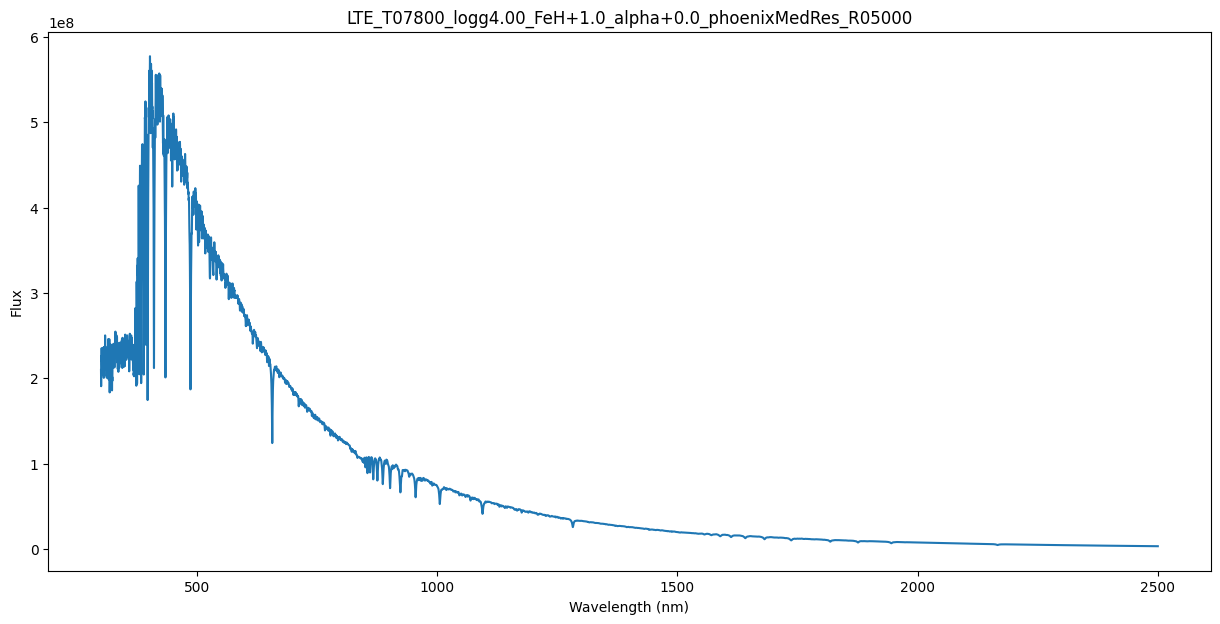

In [9]:
plt.figure(figsize = (15, 7))
plt.plot(dict_toy["wav"], dict_toy["flux"])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.title(file.stem)
plt.plot()

FeH+0.5_alpha+0.0_phoenixMedRes_R05000
FeH+1.0_alpha+0.0_phoenixMedRes_R05000


[]

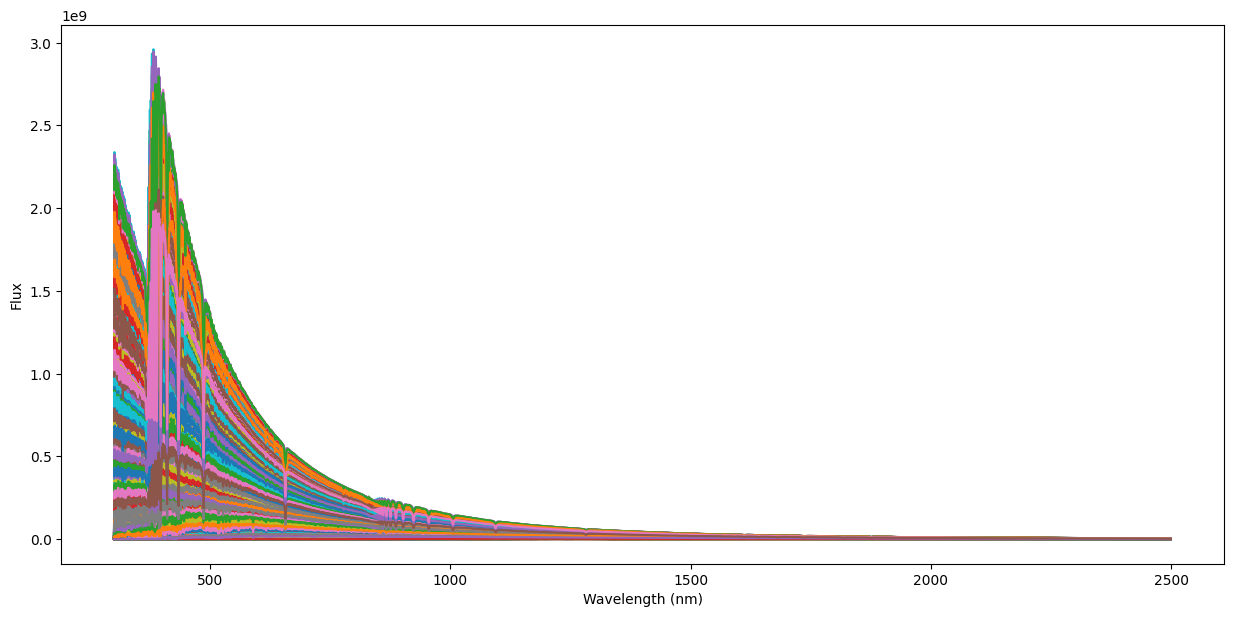

In [10]:
plt.figure(figsize = (15, 7))
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")

for i, folder in enumerate(path.iterdir()):
    if folder.is_dir():
        print(folder.name)
        for file in folder.iterdir():
            if file.suffix == ".txt":  # skip lock files etc.
                dict_toy = dict[file.stem]
                plt.plot(dict_toy["wav"], dict_toy["flux"])
                if i > 10:
                    break
plt.plot()

In [ ]:
'''
Put all the stellar spectra in a h5 file between wavelengths 0.5 to 1.8 um 
rebin to a common wavelength grid. 
save the h5 file in a data folder. 
'''